Q1. Missing Data Identification

**Scenario:**  
The hospital suspects incomplete patient records.

**Task:**  
- Identify missing values in each column  
- Calculate percentage of missing data


In [1]:
import pandas as pd
import os

file_name = "healthcare_data_cleaning_dataset.csv"
possible_paths = [file_name, "/mnt/data/healthcare_data_cleaning_dataset.csv"]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break

if df is None:
    print("Dataset file not found.")
else:
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100

    print("Missing values in each column:")
    print(missing_values)
    print()
    print("Percentage of missing data:")
    print(missing_percentage.round(2))


Missing values in each column:
Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64

Percentage of missing data:
Patient_ID             0.00
Age                   11.76
Gender                 0.00
City                   0.00
Diagnosis              0.00
Hospital_Visits        0.00
Treatment_Cost        11.63
Insurance_Coverage     0.00
Admission_Date         0.00
dtype: float64


Q2. Handling Missing Age

**Scenario:**  
Age is critical for medical analysis, but some values are missing.

**Task:**  
- Replace missing Age values with an appropriate method  
- Justify your choice (mean/median)


In [2]:
import pandas as pd
import os

file_name = "healthcare_data_cleaning_dataset.csv"
possible_paths = [file_name, "/mnt/data/healthcare_data_cleaning_dataset.csv"]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break

if df is None:
    print("Dataset file not found.")
else:
    age_mean = df["Age"].mean()
    age_median = df["Age"].median()

    print("Mean Age:", round(age_mean, 2))
    print("Median Age:", age_median)
    print("Choice: Mean")
    print("Reason: Age values are almost symmetric, so mean is fine here.")
    print()

    print("Missing Age before fill:", df["Age"].isnull().sum())
    df["Age"] = df["Age"].fillna(age_mean)
    print("Missing Age after fill:", df["Age"].isnull().sum())
    print()
    print(df["Age"].head())


Mean Age: 49.6
Median Age: 50.0
Choice: Mean
Reason: Age values are almost symmetric, so mean is fine here.

Missing Age before fill: 600
Missing Age after fill: 0

0    35.0
1    21.0
2    77.0
3    79.0
4    60.0
Name: Age, dtype: float64


Q3. Handling Missing Treatment Cost

**Scenario:**  
Treatment cost is highly skewed due to expensive treatments.

**Task:**  
- Handle missing Treatment_Cost values  
- Choose the correct imputation method and explain why


In [3]:
import pandas as pd
import os

file_name = "healthcare_data_cleaning_dataset.csv"
possible_paths = [file_name, "/mnt/data/healthcare_data_cleaning_dataset.csv"]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break

if df is None:
    print("Dataset file not found.")
else:
    cost_mean = df["Treatment_Cost"].mean()
    cost_median = df["Treatment_Cost"].median()

    print("Mean Treatment_Cost:", round(cost_mean, 2))
    print("Median Treatment_Cost:", cost_median)
    print("Choice: Median")
    print("Reason: Treatment_Cost is skewed, so median is better.")
    print()

    print("Missing Treatment_Cost before fill:", df["Treatment_Cost"].isnull().sum())
    df["Treatment_Cost"] = df["Treatment_Cost"].fillna(cost_median)
    print("Missing Treatment_Cost after fill:", df["Treatment_Cost"].isnull().sum())
    print()
    print(df["Treatment_Cost"].head())


Mean Treatment_Cost: 26920.15
Median Treatment_Cost: 24797.0
Choice: Median
Reason: Treatment_Cost is skewed, so median is better.

Missing Treatment_Cost before fill: 593
Missing Treatment_Cost after fill: 0

0    41010.0
1    12194.0
2    45086.0
3    40842.0
4     9873.0
Name: Treatment_Cost, dtype: float64


Q4. Duplicate Patient Records

**Scenario:**  
Some patient records were entered multiple times.

**Task:**  
- Identify duplicate rows  
- Remove duplicates  
- Compare dataset size before and after


In [4]:
import pandas as pd
import os

file_name = "healthcare_data_cleaning_dataset.csv"
possible_paths = [file_name, "/mnt/data/healthcare_data_cleaning_dataset.csv"]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break

if df is None:
    print("Dataset file not found.")
else:
    before_shape = df.shape
    duplicate_count = df.duplicated().sum()
    df_clean = df.drop_duplicates()
    after_shape = df_clean.shape

    print("Duplicate rows:", duplicate_count)
    print("Dataset size before removing duplicates:", before_shape)
    print("Dataset size after removing duplicates:", after_shape)


Duplicate rows: 99
Dataset size before removing duplicates: (5100, 9)
Dataset size after removing duplicates: (5001, 9)


Q5. Invalid Age Values (Data Quality Check)

**Scenario:**  
Some patients have unrealistic age values (e.g., >100 or <0).

**Task:**  
- Detect such records  
- Decide whether to remove or correct them


In [5]:
import pandas as pd
import os

file_name = "healthcare_data_cleaning_dataset.csv"
possible_paths = [file_name, "/mnt/data/healthcare_data_cleaning_dataset.csv"]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break

if df is None:
    print("Dataset file not found.")
else:
    invalid_age = df[(df["Age"] < 0) | (df["Age"] > 100)]

    print("Invalid age records:")
    print(invalid_age)
    print()
    print("Total invalid age records:", len(invalid_age))

    if len(invalid_age) == 0:
        print("No invalid age values found, so no rows were removed or corrected.")
    else:
        df = df[(df["Age"] >= 0) & (df["Age"] <= 100)]
        print("Invalid age values removed.")


Invalid age records:
Empty DataFrame
Columns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]
Index: []

Total invalid age records: 0
No invalid age values found, so no rows were removed or corrected.


Q6. Outlier Detection (Treatment Cost)

**Scenario:**  
Extreme treatment costs are affecting analysis.

**Task:**  
- Detect outliers using IQR method  
- Display number of outliers


In [6]:
import pandas as pd
import os

file_name = "healthcare_data_cleaning_dataset.csv"
possible_paths = [file_name, "/mnt/data/healthcare_data_cleaning_dataset.csv"]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break

if df is None:
    print("Dataset file not found.")
else:
    Q1 = df["Treatment_Cost"].quantile(0.25)
    Q3 = df["Treatment_Cost"].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df["Treatment_Cost"] < lower_bound) | (df["Treatment_Cost"] > upper_bound)]

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of outliers:", len(outliers))


Q1: 12498.0
Q3: 37922.0
IQR: 25424.0
Lower Bound: -25638.0
Upper Bound: 76058.0
Number of outliers: 50


Q7. Outlier Treatment

**Scenario:**  
The business team wants to retain all records.

**Task:**  
- Apply capping (Winsorization) on Treatment_Cost  
- Use 5th and 95th percentile


In [7]:
import pandas as pd
import os

file_name = "healthcare_data_cleaning_dataset.csv"
possible_paths = [file_name, "/mnt/data/healthcare_data_cleaning_dataset.csv"]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break

if df is None:
    print("Dataset file not found.")
else:
    lower_cap = df["Treatment_Cost"].quantile(0.05)
    upper_cap = df["Treatment_Cost"].quantile(0.95)

    df["Treatment_Cost_Capped"] = df["Treatment_Cost"].clip(lower=lower_cap, upper=upper_cap)

    print("5th percentile:", lower_cap)
    print("95th percentile:", upper_cap)
    print()
    print("Original min and max:")
    print(df["Treatment_Cost"].min(), df["Treatment_Cost"].max())
    print()
    print("Capped min and max:")
    print(df["Treatment_Cost_Capped"].min(), df["Treatment_Cost_Capped"].max())


5th percentile: 2914.6
95th percentile: 48188.1

Original min and max:
526.0 199702.96533333333

Capped min and max:
2914.6 48188.1


Q8. Transformation

**Scenario:**  
Treatment cost is highly skewed.

**Task:**  
- Apply log transformation  
- Create a new column  
- Compare before vs after distribution


   Treatment_Cost_Filled  Log_Treatment_Cost
0                41010.0           10.621571
1                12194.0            9.408699
2                45086.0           10.716327
3                40842.0           10.617466
4                 9873.0            9.197559


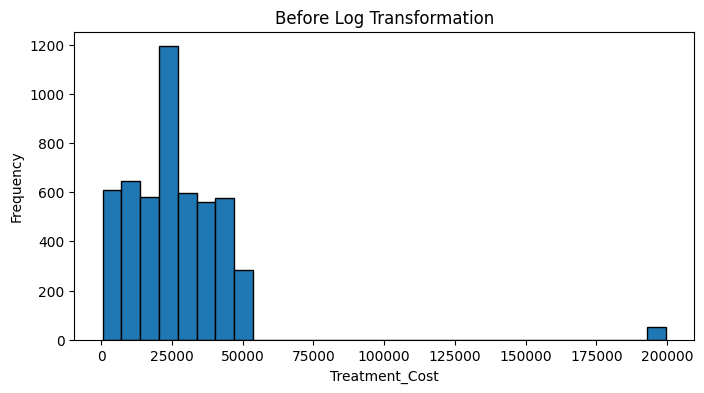

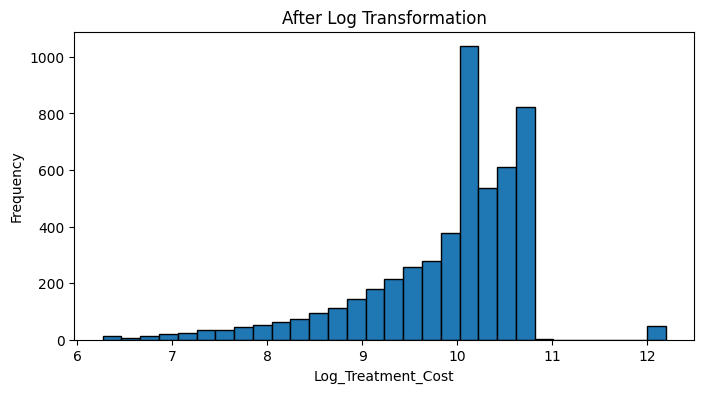

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

file_name = "healthcare_data_cleaning_dataset.csv"
possible_paths = [file_name, "/mnt/data/healthcare_data_cleaning_dataset.csv"]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break

if df is None:
    print("Dataset file not found.")
else:
    median_cost = df["Treatment_Cost"].median()
    df["Treatment_Cost_Filled"] = df["Treatment_Cost"].fillna(median_cost)
    df["Log_Treatment_Cost"] = np.log(df["Treatment_Cost_Filled"])

    print(df[["Treatment_Cost_Filled", "Log_Treatment_Cost"]].head())

    plt.figure(figsize=(8, 4))
    plt.hist(df["Treatment_Cost_Filled"], bins=30, edgecolor="black")
    plt.title("Before Log Transformation")
    plt.xlabel("Treatment_Cost")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(df["Log_Treatment_Cost"], bins=30, edgecolor="black")
    plt.title("After Log Transformation")
    plt.xlabel("Log_Treatment_Cost")
    plt.ylabel("Frequency")
    plt.show()


Q9. Time-Based Missing Handling

**Scenario:**  
Admission dates should follow a logical sequence.

**Task:**  
- Sort data by Admission_Date  
- Apply forward fill or backward fill where appropriate  
- Justify your choice


In [9]:
import pandas as pd
import os

file_name = "healthcare_data_cleaning_dataset.csv"
possible_paths = [file_name, "/mnt/data/healthcare_data_cleaning_dataset.csv"]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break

if df is None:
    print("Dataset file not found.")
else:
    df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
    df = df.sort_values("Admission_Date")

    print("Missing values before fill:")
    print(df[["Age", "Treatment_Cost"]].isnull().sum())
    print()

    df[["Age", "Treatment_Cost"]] = df[["Age", "Treatment_Cost"]].ffill().bfill()

    print("Missing values after fill:")
    print(df[["Age", "Treatment_Cost"]].isnull().sum())
    print()
    print("Choice: Forward fill")
    print("Reason: After sorting by date, previous values are used first. Backward fill is used only if the first rows are missing.")
    print()
    print(df[["Admission_Date", "Age", "Treatment_Cost"]].head())


Missing values before fill:
Age               600
Treatment_Cost    593
dtype: int64

Missing values after fill:
Age               0
Treatment_Cost    0
dtype: int64

Choice: Forward fill
Reason: After sorting by date, previous values are used first. Backward fill is used only if the first rows are missing.

     Admission_Date   Age  Treatment_Cost
2702     2023-01-01  41.0    12398.000000
2624     2023-01-01  57.0    39718.000000
1791     2023-01-01  94.0    23388.000000
4292     2023-01-01  25.0   199702.965333
2642     2023-01-01  25.0   199702.965333
